# Assignment 4 - Portugal
# PyPSA Model & Sensitivity Analysis
Requires outputs from `EAnalysis.ipynb`.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
import pypsa, xarray as xr
from pypsa.costs import annuity

url_dataset = 'https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq'
url_tech_cost = 'https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_2030.csv'
url_load = f'{url_dataset}/download?path=%2Fgegis&files=load.csv'
url_pp   = f'{url_dataset}/download?path=%2Fglobal-power-plant-database&files=global_power_plant_database.csv'

pypsa.options.params.optimize.include_objective_constant = True

## Load EAnalysis Data

In [2]:
regions          = gpd.read_file('regions.gpkg')                 # [EPSG:3035, m]
regions          = regions.set_index('nuts2')
regions['representative_point'] = regions.geometry.representative_point()

offshore_valid   = gpd.read_file('offshore_valid.gpkg').set_index('nuts2')  # [EPSG:3035, m]

# Capacity factor (3h resolution)
cf_wind          = xr.open_dataarray('cf_wind.nc')               # [-]
cf_solar         = xr.open_dataarray('cf_solar.nc')              # [-]
cf_offshore      = xr.open_dataarray('cf_offshore.nc')           # [-]

p_nom_max_wind     = pd.read_csv('p_nom_max_wind.csv',     index_col=0)['p_nom_max_MW']  # [MW]
p_nom_max_solar    = pd.read_csv('p_nom_max_solar.csv',    index_col=0)['p_nom_max_MW']  # [MW]
p_nom_max_offshore = pd.read_csv('p_nom_max_offshore.csv', index_col=0)['p_nom_max_MW']  # [MW]

print('Regions:', list(regions.index))
print('cf wind dim:', cf_wind.dims)
print('p_nom_max_offshore:\n', p_nom_max_offshore)

Regions: ['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte']
cf wind dim: ('time', 'nuts2')
p_nom_max_offshore:
 nuts2
Alentejo     5512.750661
Algarve     83465.168955
Centro      65569.599010
Lisboa      58028.784018
Norte       39911.710456
Name: p_nom_max_MW, dtype: float64


## 1. Technology costs (2030)

In [3]:
costs = pd.read_csv(url_tech_cost, index_col=[0, 1])

costs.loc[costs.unit.str.contains('/kW'), 'value'] *= 1e3        # [EUR/MW] 
costs.unit = costs.unit.str.replace('/kW', '/MW')

defaults = {'FOM': 0,               # [%/a] fixed O&M as share of investment
            'VOM': 0,               # [EUR/MWh_el]
            'efficiency': 1,        # [-]
            'fuel': 0,              # [EUR/MWh_th]
            'investment': 0,        # [EUR/MW]
            'lifetime': 25,         # [a]
            'CO2 intensity': 0,     # [t_CO2/MWh_th]
            'discount rate': 0.07}  # [-]
costs = costs.value.unstack().fillna(defaults)

# Gas carriers inherit fuel cost + CO2 from 'gas'
for t in ['OCGT', 'CCGT']:
    costs.at[t, 'fuel']          = costs.at['gas', 'fuel']           # [EUR/MWh_th]
    costs.at[t, 'CO2 intensity'] = costs.at['gas', 'CO2 intensity']  # [t_CO2/MWh_th]

costs['marginal_cost'] = costs['VOM'] + costs['fuel'] / costs['efficiency']  # [EUR/MWh_el]
annuity_factor = annuity(costs['discount rate'], costs['lifetime'])          # [1/a]
costs['capital_cost'] = (annuity_factor + costs['FOM'] / 100) * costs['investment']  # [EUR/MW/a]

check = ['solar', 'onwind', 'offwind', 'offwind-float', 'OCGT', 'CCGT',
         'battery storage', 'battery inverter', 'electrolysis', 'fuel cell',
         'hydrogen storage underground']
costs.loc[check, ['investment', 'lifetime', 'marginal_cost', 'capital_cost']].round(1)

parameter,investment,lifetime,marginal_cost,capital_cost
technology,,,,
solar,683146.2,40.0,0.0,64560.1
onwind,1383305.9,30.0,1.8,128306.3
offwind,2114991.0,30.0,0.0,219475.6
offwind-float,2954736.3,20.0,0.0,312885.7
OCGT,581394.9,25.0,75.3,60235.7
CCGT,1108716.6,25.0,54.6,132274.9
battery storage,189861.0,25.0,0.0,16292.1
battery inverter,213927.9,10.0,0.0,31180.5
electrolysis,1886001.9,25.0,0.0,237278.9


## 2. Load time series

In [4]:
load_raw    = pd.read_csv(url_load, index_col=0, parse_dates=True)  # [MW] country-level load
load_pt     = load_raw['PT'].loc['2013'].resample('3h').mean()      # [MW] 3h averages
population  = pd.Series({'Norte': 3689, 'Centro': 2227, 'Lisboa': 2821,
                          'Alentejo': 757, 'Algarve': 451})          # [thousand people] 2021 census
pop_share   = population / population.sum()                          # [-] share
load_region = pd.DataFrame({r: load_pt * pop_share[r] for r in regions.index})  # [MW] 
print('Load shape:', load_region.shape)
load_region.head(2)

Load shape: (2920, 5)


,Alentejo,Algarve,Centro,Lisboa,Norte
time,,,,,
2013-01-01 00:00:00,443.115591,263.996211,1303.591044,1651.293370,2159.383638
2013-01-01 03:00:00,416.359499,248.055659,1224.877944,1551.585397,2028.996289


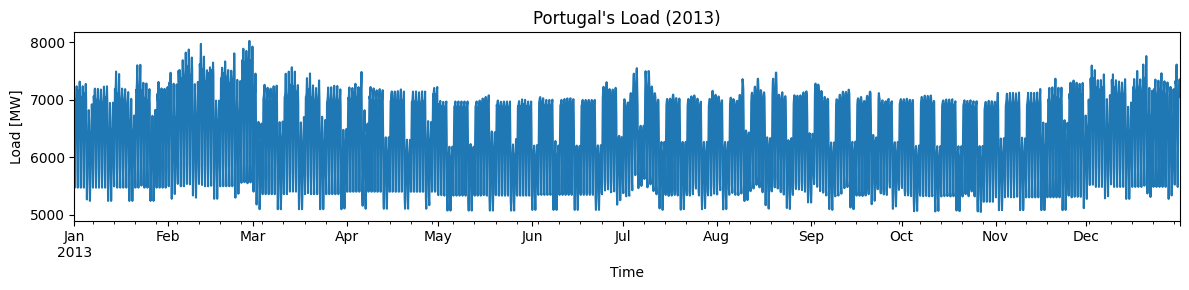

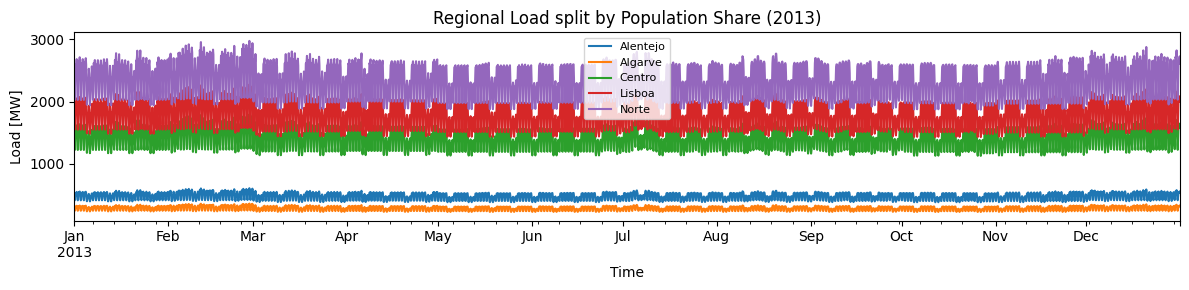

In [5]:
# --- national + regional load time series ---
load_pt.plot(figsize=(12, 3), title='Portugal\'s Load (2013)')     
plt.ylabel('Load [MW]')
plt.xlabel('Time')
plt.tight_layout()
plt.show()

load_region.plot(figsize=(12, 3), title='Regional Load split by Population Share (2013)')
plt.ylabel('Load [MW]')
plt.xlabel('Time')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Existing Power Plants

In [6]:
pp_raw  = pd.read_csv(url_pp, low_memory=False)
pp_pt   = pp_raw[(pp_raw['country'] == 'PRT') &
                  ~pp_raw['primary_fuel'].isin(['Wind', 'Solar'])].copy()
pp_pt   = pp_pt.dropna(subset=['latitude', 'longitude'])            # [deg]
pp_gdf  = gpd.GeoDataFrame(pp_pt,
           geometry=gpd.points_from_xy(pp_pt.longitude, pp_pt.latitude),
           crs=4326).to_crs(3035)                                   # [EPSG:3035, m]
pp_join = gpd.sjoin_nearest(pp_gdf, regions[['geometry']].reset_index(),
                             how='left', distance_col='dist')       # [m]

hydro     = pp_join[pp_join['primary_fuel'] == 'Hydro']
hydro_cap = hydro.groupby('nuts2')['capacity_mw'].sum()             # [MW]

# Uses estimated generation if actual 2013 column is missing/all-NaN
gen_col = 'generation_gwh_2013'
if gen_col not in hydro.columns or hydro[gen_col].isna().all():
    gen_col = 'estimated_generation_gwh_2013'
hydro_gen = hydro.groupby('nuts2')[gen_col].sum()                   # [GWh/a]
hydro_cf  = (hydro_gen * 1000 / (hydro_cap * 8760)).clip(0, 1).fillna(0.15)  # [-] capacity factor

non_hydro    = pp_join[pp_join['primary_fuel'] != 'Hydro']
conventional = non_hydro.groupby(['nuts2', 'primary_fuel'])['capacity_mw'] \
                         .sum().unstack(fill_value=0)               # [MW]

print('Hydro CF:\n', hydro_cf.round(3))
print('Conventional [MW]:\n', conventional)

Hydro CF:
 nuts2
Alentejo    0.366
Algarve     0.332
Centro      0.322
Lisboa      0.342
Norte       0.311
dtype: float64
Conventional [MW]:
 primary_fuel  Biomass    Coal     Gas  Geothermal  Waste
nuts2                                                   
Algarve           0.0     0.0     0.0         0.0   10.9
Centro          347.7   682.0  1663.0        28.8   18.5
Lisboa           66.4  1296.0  1176.0         0.0   62.2
Norte            38.8     0.0   990.0         0.0   40.2


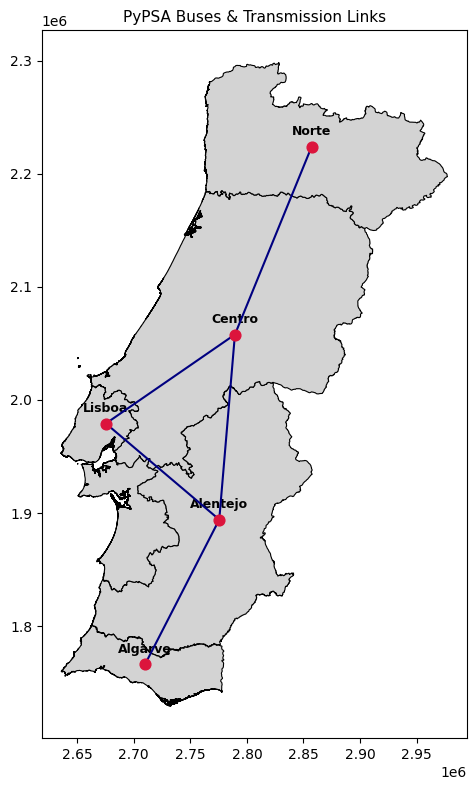

In [7]:
# --- model regions as PyPSA buses + transmission topology ---
lines = [('Norte','Centro'), ('Centro','Lisboa'), ('Centro','Alentejo'),
         ('Lisboa','Alentejo'), ('Alentejo','Algarve')]

fig, ax = plt.subplots(figsize=(6, 8))
regions.plot(ax=ax, color='lightgrey', edgecolor='k', linewidth=0.8)
for region, row in regions.iterrows():
    pt = row['representative_point']
    ax.scatter(pt.x, pt.y, color='crimson', s=60, zorder=5)
    ax.annotate(region, (pt.x, pt.y), xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold')
for r1, r2 in lines:
    p1, p2 = regions.at[r1, 'representative_point'], regions.at[r2, 'representative_point']
    ax.plot([p1.x, p2.x], [p1.y, p2.y], color='navy', linewidth=1.5, zorder=4)
ax.set_title('PyPSA Buses & Transmission Links', fontsize=11)
plt.tight_layout()
plt.show()

## 4. `build_network()` function

In [8]:
def build_network(solar_cost_factor=1.0):
    n = pypsa.Network()
    n.set_snapshots(load_region.index)                              # [3h] 2920 snapshots

    # Buses
    for region, row in regions.iterrows():
        pt = row['representative_point']                            # [m] EPSG:3035
        n.add('Bus', region, x=pt.x, y=pt.y, carrier='AC')

    # Loads
    for region in regions.index:
        n.add('Load', f'load-{region}', bus=region, p_set=load_region[region])  # [MW]

    # Hydro (capacity factor = const.)
    for region in regions.index:
        cap = float(hydro_cap.get(region, 0))                       # [MW]
        if cap > 0:
            n.add('Generator', f'hydro-{region}', bus=region, carrier='hydro',
                  p_nom=cap, p_nom_extendable=False,                # [MW]
                  p_max_pu=float(hydro_cf.get(region, 0.15)),       # [-]
                  marginal_cost=0., capital_cost=0.)                # [EUR/MWh], [EUR/MW/a]

    # CO2 carriers
    n.add('Carrier', 'gas',     co2_emissions=costs.at['gas',  'CO2 intensity'])  # [t_CO2/MWh_th]
    n.add('Carrier', 'coal',    co2_emissions=costs.at['coal', 'CO2 intensity'])  # [t_CO2/MWh_th]
    n.add('Carrier', 'biomass', co2_emissions=0.)                   # [t_CO2/MWh_th]
    n.add('Carrier', 'waste',   co2_emissions=0.)                   # [t_CO2/MWh_th]

    # Existing conventional fleet
    biomass_mc = costs.at['biomass', 'marginal_cost'] if 'biomass' in costs.index else 3.0  # [EUR/MWh_el]
    fuel_map = {
        'Gas':     ('gas',     costs.at['CCGT', 'marginal_cost']),  # [EUR/MWh_el]
        'Coal':    ('coal',    costs.at['coal', 'marginal_cost']),  # [EUR/MWh_el]
        'Biomass': ('biomass', biomass_mc),                         # [EUR/MWh_el]
        'Waste':   ('waste',   biomass_mc),                         # [EUR/MWh_el]
    }
    for fuel, (carrier, mc) in fuel_map.items():
        if fuel not in conventional.columns: continue
        for region in regions.index:
            if region not in conventional.index: continue
            cap = float(conventional.at[region, fuel])              # [MW]
            if cap > 0:
                n.add('Generator', f'{fuel.lower()}-{region}', bus=region,
                      carrier=carrier, p_nom=cap, p_nom_extendable=False,  # [MW]
                      marginal_cost=mc, capital_cost=0.)            # [EUR/MWh], [EUR/MW/a]

    # Renewable generators (extendable)
    solar_cc = costs.at['solar', 'capital_cost'] * solar_cost_factor  # [EUR/MW/a]
    for region in regions.index:
        n.add('Generator', f'onwind-{region}', bus=region, carrier='onwind',
              p_nom_extendable=True,
              p_nom_max=float(p_nom_max_wind.get(region, 0)),       # [MW]
              p_max_pu=cf_wind.sel(nuts2=region).values,            # [-]
              capital_cost=costs.at['onwind', 'capital_cost'],      # [EUR/MW/a]
              marginal_cost=costs.at['onwind', 'marginal_cost'])    # [EUR/MWh]
        n.add('Generator', f'solar-{region}', bus=region, carrier='solar',
              p_nom_extendable=True,
              p_nom_max=float(p_nom_max_solar.get(region, 0)),      # [MW]
              p_max_pu=cf_solar.sel(nuts2=region).values,           # [-]
              capital_cost=solar_cc,                                # [EUR/MW/a]
              marginal_cost=costs.at['solar', 'marginal_cost'])     # [EUR/MWh]
        if float(p_nom_max_offshore.get(region, 0)) > 0:
            n.add('Generator', f'offwind-{region}', bus=region, carrier='offwind',
                  p_nom_extendable=True,
                  p_nom_max=float(p_nom_max_offshore.get(region, 0)),  # [MW]
                  p_max_pu=cf_offshore.sel(nuts2=region).values,    # [-]
                  capital_cost=costs.at['offwind-float', 'capital_cost'],  # [EUR/MW/a]
                  marginal_cost=costs.at['offwind-float', 'marginal_cost'])  # [EUR/MWh]
        n.add('Generator', f'OCGT-{region}', bus=region, carrier='gas',
              p_nom_extendable=True,
              capital_cost=costs.at['OCGT', 'capital_cost'],        # [EUR/MW/a]
              marginal_cost=costs.at['OCGT', 'marginal_cost'])      # [EUR/MWh]

    # Transmission links
    for r1, r2 in [('Norte','Centro'), ('Centro','Lisboa'), ('Centro','Alentejo'),
                   ('Lisboa','Alentejo'), ('Alentejo','Algarve')]:
        pt1 = regions.at[r1, 'representative_point']
        pt2 = regions.at[r2, 'representative_point']
        dist_km = pt1.distance(pt2) / 1000 * 1.5                    # [km] incl. detour factor
        n.add('Link', f'line-{r1}-{r2}', bus0=r1, bus1=r2, p_min_pu=-1,
              p_nom_extendable=True, capital_cost=700 * dist_km, marginal_cost=0.)  # [EUR/MW/a]

    # Battery storage (4h)
    batt_cc   = costs.at['battery inverter', 'capital_cost']        # [EUR/MW/a]
    batt_e_cc = costs.at['battery storage',  'capital_cost']        # [EUR/MWh/a]
    for region in regions.index:
        n.add('StorageUnit', f'battery-{region}', bus=region, carrier='battery',
              p_nom_extendable=True, max_hours=4,                   # [h] energy/power ratio
              capital_cost=batt_cc + 4 * batt_e_cc,                 # [EUR/MW/a]
              efficiency_store=costs.at['battery inverter', 'efficiency'],     # [-]
              efficiency_dispatch=costs.at['battery inverter', 'efficiency'],  # [-]
              cyclic_state_of_charge=True)

    # Hydrogen storage (168h)
    h2_power_cc  = costs.at['electrolysis', 'capital_cost'] + costs.at['fuel cell', 'capital_cost']  # [EUR/MW/a]
    h2_energy_cc = costs.at['hydrogen storage underground', 'capital_cost']    # [EUR/MWh/a]
    for region in regions.index:
        n.add('StorageUnit', f'H2-{region}', bus=region, carrier='H2',
              p_nom_extendable=True, max_hours=168,                 # [h] energy/power ratio
              capital_cost=h2_power_cc + 168 * h2_energy_cc,        # [EUR/MW/a]
              efficiency_store=costs.at['electrolysis', 'efficiency'],   # [-]
              efficiency_dispatch=costs.at['fuel cell', 'efficiency'],   # [-]
              cyclic_state_of_charge=True)
    return n
print(f'Solar base capital cost: {costs.at["solar", "capital_cost"]:.0f} EUR/MW/a')

Solar base capital cost: 64560 EUR/MW/a


## 5. No CO₂ limit

In [9]:
n_free = build_network(solar_cost_factor=1.0)
n_free.optimize(solver_name='highs')
print('=== No CO2 limit ===')
print(f'Total cost: {n_free.objective/1e9:.2f} bn EUR/yr')
print(n_free.generators.groupby('carrier')['p_nom_opt'].sum().round(0))
n_free.export_to_netcdf('network_free.nc')

Index(['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte'], dtype='object', name='name')
Index(['hydro-Alentejo', 'hydro-Algarve', 'hydro-Centro', 'hydro-Lisboa',
       'hydro-Norte', 'onwind-Alentejo', 'solar-Alentejo', 'offwind-Alentejo',
       'onwind-Algarve', 'solar-Algarve', 'offwind-Algarve', 'onwind-Centro',
       'solar-Centro', 'offwind-Centro', 'onwind-Lisboa', 'solar-Lisboa',
       'offwind-Lisboa', 'onwind-Norte', 'solar-Norte', 'offwind-Norte'],
      dtype='object', name='name')
Index(['line-Norte-Centro', 'line-Centro-Lisboa', 'line-Centro-Alentejo',
       'line-Lisboa-Alentejo', 'line-Alentejo-Algarve'],
      dtype='object', name='name')
Index(['battery-Alentejo', 'battery-Algarve', 'battery-Centro',
       'battery-Lisboa', 'battery-Norte', 'H2-Alentejo', 'H2-Algarve',
       'H2-Centro', 'H2-Lisboa', 'H2-Norte'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.

=== No CO2 limit ===
Total cost: 0.87 bn EUR/yr
carrier
biomass     453.0
coal       1978.0
gas        6017.0
hydro      2760.0
offwind       0.0
onwind        0.0
solar         0.0
waste       132.0
Name: p_nom_opt, dtype: float64


<xarray.Dataset> Size: 2MB
Dimensions:                               (snapshots: 2920, buses_i: 5,
                                           buses_t_p_i: 3,
                                           buses_t_marginal_price_i: 5,
                                           generators_i: 37,
                                           generators_t_p_max_pu_i: 15,
                                           generators_t_p_i: 20, loads_i: 5,
                                           loads_t_p_set_i: 5, loads_t_p_i: 5,
                                           storage_units_i: 10,
                                           storage_units_t_state_of_charge_i: 10,
                                           links_i: 5, carriers_i: 4,
                                           sub_networks_i: 5)
Coordinates: (12/15)
  * snapshots                             (snapshots) int64 23kB 0 1 ... 2919
  * buses_i                               (buses_i) object 40B 'Alentejo' ......
  * buses_t_p_i                           (buses_t_p_i) object 24B 'Algarve' ...
  * buses_t_marginal_price_i              (buses_t_marginal_price_i) object 40B ...
  * generators_i                          (generators_i) object 296B 'hydro-A...
  * generators_t_p_max_pu_i               (generators_t_p_max_pu_i) object 120B ...
    ...                                    ...
  * loads_t_p_i                           (loads_t_p_i) object 40B 'load-Alen...
  * storage_units_i                       (storage_units_i) object 80B 'batte...
  * storage_units_t_state_of_charge_i     (storage_units_t_state_of_charge_i) object 80B ...
  * links_i                               (links_i) object 40B 'line-Norte-Ce...
  * carriers_i                            (carriers_i) object 32B 'gas' ... '...
  * sub_networks_i                        (sub_networks_i) object 40B '0' ......
Data variables: (12/44)
    snapshots_snapshot                    (snapshots) datetime64[ns] 23kB 201...
    snapshots_objective                   (snapshots) float64 23kB 1.0 ... 1.0
    snapshots_stores                      (snapshots) float64 23kB 1.0 ... 1.0
    snapshots_generators                  (snapshots) float64 23kB 1.0 ... 1.0
    buses_x                               (buses_i) float64 40B 2.776e+06 ......
    buses_y                               (buses_i) float64 40B 1.894e+06 ......
    ...                                    ...
    links_p_nom_extendable                (links_i) bool 5B True True ... True
    links_p_min_pu                        (links_i) float64 40B -1.0 ... -1.0
    links_capital_cost                    (links_i) float64 40B 1.884e+05 ......
    carriers_co2_emissions                (carriers_i) float64 32B 0.198 ... 0.0
    sub_networks_slack_bus                (sub_networks_i) object 40B 'Alente...
    sub_networks_obj                      (sub_networks_i) float64 40B nan .....
Attributes:
    network__linearized_uc:       0
    network__multi_invest:        0
    network__objective:           869596265.1561012
    network__objective_constant:  0.0
    network_name:                 Unnamed Network
    network_pypsa_version:        1.1.2
    network_srid:                 4326
    crs:                          {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Wor...
    meta:                         {}

## 6. Net Zero

In [10]:
n_zero = build_network(solar_cost_factor=1.0)
n_zero.add('GlobalConstraint', 'co2_limit', sense='<=', constant=0.,
           carrier_attribute='co2_emissions')
n_zero.optimize(solver_name='highs')
print('=== Zero CO2 ===')
print(f'Total cost: {n_zero.objective/1e9:.2f} bn EUR/yr')
print(n_zero.generators.groupby('carrier')['p_nom_opt'].sum().round(0))
n_zero.export_to_netcdf('network_zero.nc')

Index(['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte'], dtype='object', name='name')
Index(['hydro-Alentejo', 'hydro-Algarve', 'hydro-Centro', 'hydro-Lisboa',
       'hydro-Norte', 'onwind-Alentejo', 'solar-Alentejo', 'offwind-Alentejo',
       'onwind-Algarve', 'solar-Algarve', 'offwind-Algarve', 'onwind-Centro',
       'solar-Centro', 'offwind-Centro', 'onwind-Lisboa', 'solar-Lisboa',
       'offwind-Lisboa', 'onwind-Norte', 'solar-Norte', 'offwind-Norte'],
      dtype='object', name='name')
Index(['line-Norte-Centro', 'line-Centro-Lisboa', 'line-Centro-Alentejo',
       'line-Lisboa-Alentejo', 'line-Alentejo-Algarve'],
      dtype='object', name='name')
Index(['battery-Alentejo', 'battery-Algarve', 'battery-Centro',
       'battery-Lisboa', 'battery-Norte', 'H2-Alentejo', 'H2-Algarve',
       'H2-Centro', 'H2-Lisboa', 'H2-Norte'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.

=== Zero CO2 ===
Total cost: 4.66 bn EUR/yr
carrier
biomass      453.0
coal        1978.0
gas         3829.0
hydro       2760.0
offwind     3130.0
onwind      1998.0
solar      26988.0
waste        132.0
Name: p_nom_opt, dtype: float64


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'network_zero.nc contains: buses, generators, loads, storage_units, links, carriers, sub_networks, global_constraints


<xarray.Dataset> Size: 3MB
Dimensions:                               (snapshots: 2920, buses_i: 5,
                                           buses_t_p_i: 5,
                                           buses_t_marginal_price_i: 5,
                                           generators_i: 37,
                                           generators_t_p_max_pu_i: 15,
                                           generators_t_p_i: 22, loads_i: 5,
                                           ...
                                           storage_units_t_p_store_i: 9,
                                           storage_units_t_state_of_charge_i: 10,
                                           links_i: 5, links_t_p0_i: 5,
                                           links_t_p1_i: 5, carriers_i: 4,
                                           sub_networks_i: 5,
                                           global_constraints_i: 1)
Coordinates: (12/21)
  * snapshots                             (snapshots) int64 23kB 0 1 ... 2919
  * buses_i                               (buses_i) object 40B 'Alentejo' ......
  * buses_t_p_i                           (buses_t_p_i) object 40B 'Alentejo'...
  * buses_t_marginal_price_i              (buses_t_marginal_price_i) object 40B ...
  * generators_i                          (generators_i) object 296B 'hydro-A...
  * generators_t_p_max_pu_i               (generators_t_p_max_pu_i) object 120B ...
    ...                                    ...
  * links_i                               (links_i) object 40B 'line-Norte-Ce...
  * links_t_p0_i                          (links_t_p0_i) object 40B 'line-Nor...
  * links_t_p1_i                          (links_t_p1_i) object 40B 'line-Nor...
  * carriers_i                            (carriers_i) object 32B 'gas' ... '...
  * sub_networks_i                        (sub_networks_i) object 40B '0' ......
  * global_constraints_i                  (global_constraints_i) object 8B 'c...
Data variables: (12/53)
    snapshots_snapshot                    (snapshots) datetime64[ns] 23kB 201...
    snapshots_objective                   (snapshots) float64 23kB 1.0 ... 1.0
    snapshots_stores                      (snapshots) float64 23kB 1.0 ... 1.0
    snapshots_generators                  (snapshots) float64 23kB 1.0 ... 1.0
    buses_x                               (buses_i) float64 40B 2.776e+06 ......
    buses_y                               (buses_i) float64 40B 1.894e+06 ......
    ...                                    ...
    links_t_p1                            (snapshots, links_t_p1_i) float64 117kB ...
    carriers_co2_emissions                (carriers_i) float64 32B 0.198 ... 0.0
    sub_networks_slack_bus                (sub_networks_i) object 40B 'Alente...
    sub_networks_obj                      (sub_networks_i) float64 40B nan .....
    global_constraints_sense              (global_constraints_i) object 8B '<='
    global_constraints_mu                 (global_constraints_i) float64 8B -...
Attributes:
    network__linearized_uc:       0
    network__multi_invest:        0
    network__objective:           4661494269.338575
    network__objective_constant:  0.0
    network_name:                 Unnamed Network
    network_pypsa_version:        1.1.2
    network_srid:                 4326
    crs:                          {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Wor...
    meta:                         {}

## 7. Sensitivity Analysis
## Solar PV Capital Cost

Reduce solar cost from 100% → 75% → 50% → 25% → 0% under net-zero CO₂ constraint.

In [11]:
# Helper, solves one net-zero scenario with scaled solar cost and collects the results
def run_sensitivity(factor):
    print(f'Solving: solar cost = {factor*100:.0f}% ...', flush=True)
    net = build_network(solar_cost_factor=factor)
    net.add('GlobalConstraint', 'co2_limit', sense='<=', constant=0.,   # [t_CO2/a]
            carrier_attribute='co2_emissions')
    net.optimize(solver_name='highs')

    caps = net.generators.groupby('carrier')['p_nom_opt'].sum()         # [MW]
    stor = net.storage_units.groupby('carrier')['p_nom_opt'].sum()      # [MW]
    row = {
        'solar_cost_pct':    f'{factor*100:.0f}%',
        'total_cost_bn_eur': net.objective / 1e9,                       # [bn EUR/a]
        'solar_GW':          caps.get('solar',   0) / 1e3,              # [GW]
        'onwind_GW':         caps.get('onwind',  0) / 1e3,              # [GW]
        'offwind_GW':        caps.get('offwind', 0) / 1e3,              # [GW]
        'gas_GW':            caps.get('gas',     0) / 1e3,              # [GW] existing CCGT + new OCGT
        'battery_GW':        stor.get('battery', 0) / 1e3,              # [GW]
        'H2_GW':             stor.get('H2',      0) / 1e3,              # [GW]
        'transmission_GW':   net.links['p_nom_opt'].sum() / 1e3,        # [GW]
    }
    print(f'  Cost: {row["total_cost_bn_eur"]:.2f} bn EUR/yr | Solar: {row["solar_GW"]:.1f} GW')
    return row

results = []

In [12]:
# Scenario 1/5: solar cost 100%
results.append(run_sensitivity(1.0))

Solving: solar cost = 100% ...


Index(['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte'], dtype='object', name='name')
Index(['hydro-Alentejo', 'hydro-Algarve', 'hydro-Centro', 'hydro-Lisboa',
       'hydro-Norte', 'onwind-Alentejo', 'solar-Alentejo', 'offwind-Alentejo',
       'onwind-Algarve', 'solar-Algarve', 'offwind-Algarve', 'onwind-Centro',
       'solar-Centro', 'offwind-Centro', 'onwind-Lisboa', 'solar-Lisboa',
       'offwind-Lisboa', 'onwind-Norte', 'solar-Norte', 'offwind-Norte'],
      dtype='object', name='name')
Index(['line-Norte-Centro', 'line-Centro-Lisboa', 'line-Centro-Alentejo',
       'line-Lisboa-Alentejo', 'line-Alentejo-Algarve'],
      dtype='object', name='name')
Index(['battery-Alentejo', 'battery-Algarve', 'battery-Centro',
       'battery-Lisboa', 'battery-Norte', 'H2-Alentejo', 'H2-Algarve',
       'H2-Centro', 'H2-Lisboa', 'H2-Norte'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.

  Cost: 4.66 bn EUR/yr | Solar: 27.0 GW


In [13]:
# Scenario 2/5: solar cost 75%
results.append(run_sensitivity(0.75))

Solving: solar cost = 75% ...


Index(['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte'], dtype='object', name='name')
Index(['hydro-Alentejo', 'hydro-Algarve', 'hydro-Centro', 'hydro-Lisboa',
       'hydro-Norte', 'onwind-Alentejo', 'solar-Alentejo', 'offwind-Alentejo',
       'onwind-Algarve', 'solar-Algarve', 'offwind-Algarve', 'onwind-Centro',
       'solar-Centro', 'offwind-Centro', 'onwind-Lisboa', 'solar-Lisboa',
       'offwind-Lisboa', 'onwind-Norte', 'solar-Norte', 'offwind-Norte'],
      dtype='object', name='name')
Index(['line-Norte-Centro', 'line-Centro-Lisboa', 'line-Centro-Alentejo',
       'line-Lisboa-Alentejo', 'line-Alentejo-Algarve'],
      dtype='object', name='name')
Index(['battery-Alentejo', 'battery-Algarve', 'battery-Centro',
       'battery-Lisboa', 'battery-Norte', 'H2-Alentejo', 'H2-Algarve',
       'H2-Centro', 'H2-Lisboa', 'H2-Norte'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.

  Cost: 4.18 bn EUR/yr | Solar: 32.3 GW


In [14]:
# Scenario 3/5: solar cost 50%
results.append(run_sensitivity(0.50))

Solving: solar cost = 50% ...


Index(['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte'], dtype='object', name='name')
Index(['hydro-Alentejo', 'hydro-Algarve', 'hydro-Centro', 'hydro-Lisboa',
       'hydro-Norte', 'onwind-Alentejo', 'solar-Alentejo', 'offwind-Alentejo',
       'onwind-Algarve', 'solar-Algarve', 'offwind-Algarve', 'onwind-Centro',
       'solar-Centro', 'offwind-Centro', 'onwind-Lisboa', 'solar-Lisboa',
       'offwind-Lisboa', 'onwind-Norte', 'solar-Norte', 'offwind-Norte'],
      dtype='object', name='name')
Index(['line-Norte-Centro', 'line-Centro-Lisboa', 'line-Centro-Alentejo',
       'line-Lisboa-Alentejo', 'line-Alentejo-Algarve'],
      dtype='object', name='name')
Index(['battery-Alentejo', 'battery-Algarve', 'battery-Centro',
       'battery-Lisboa', 'battery-Norte', 'H2-Alentejo', 'H2-Algarve',
       'H2-Centro', 'H2-Lisboa', 'H2-Norte'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.

  Cost: 3.60 bn EUR/yr | Solar: 41.9 GW


In [15]:
# Scenario 4/5: solar cost 25%
results.append(run_sensitivity(0.25))

Solving: solar cost = 25% ...


Index(['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte'], dtype='object', name='name')
Index(['hydro-Alentejo', 'hydro-Algarve', 'hydro-Centro', 'hydro-Lisboa',
       'hydro-Norte', 'onwind-Alentejo', 'solar-Alentejo', 'offwind-Alentejo',
       'onwind-Algarve', 'solar-Algarve', 'offwind-Algarve', 'onwind-Centro',
       'solar-Centro', 'offwind-Centro', 'onwind-Lisboa', 'solar-Lisboa',
       'offwind-Lisboa', 'onwind-Norte', 'solar-Norte', 'offwind-Norte'],
      dtype='object', name='name')
Index(['line-Norte-Centro', 'line-Centro-Lisboa', 'line-Centro-Alentejo',
       'line-Lisboa-Alentejo', 'line-Alentejo-Algarve'],
      dtype='object', name='name')
Index(['battery-Alentejo', 'battery-Algarve', 'battery-Centro',
       'battery-Lisboa', 'battery-Norte', 'H2-Alentejo', 'H2-Algarve',
       'H2-Centro', 'H2-Lisboa', 'H2-Norte'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.

  Cost: 2.85 bn EUR/yr | Solar: 49.8 GW


In [16]:
# Scenario 5/5: solar cost 0%
results.append(run_sensitivity(0.0))

Solving: solar cost = 0% ...


Index(['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte'], dtype='object', name='name')
Index(['hydro-Alentejo', 'hydro-Algarve', 'hydro-Centro', 'hydro-Lisboa',
       'hydro-Norte', 'onwind-Alentejo', 'solar-Alentejo', 'offwind-Alentejo',
       'onwind-Algarve', 'solar-Algarve', 'offwind-Algarve', 'onwind-Centro',
       'solar-Centro', 'offwind-Centro', 'onwind-Lisboa', 'solar-Lisboa',
       'offwind-Lisboa', 'onwind-Norte', 'solar-Norte', 'offwind-Norte'],
      dtype='object', name='name')
Index(['line-Norte-Centro', 'line-Centro-Lisboa', 'line-Centro-Alentejo',
       'line-Lisboa-Alentejo', 'line-Alentejo-Algarve'],
      dtype='object', name='name')
Index(['battery-Alentejo', 'battery-Algarve', 'battery-Centro',
       'battery-Lisboa', 'battery-Norte', 'H2-Alentejo', 'H2-Algarve',
       'H2-Centro', 'H2-Lisboa', 'H2-Norte'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.

  Cost: 1.72 bn EUR/yr | Solar: 87.6 GW


In [17]:
df_sens = pd.DataFrame(results).drop_duplicates('solar_cost_pct', keep='last') \
                                .set_index('solar_cost_pct')
df_sens.to_csv('sensitivity_results.csv')
df_sens.round(2)

,total_cost_bn_eur,solar_GW,onwind_GW,offwind_GW,gas_GW,battery_GW,H2_GW,transmission_GW
solar_cost_pct,,,,,,,,
100%,4.66,26.99,2.00,3.13,3.83,9.85,1.06,0.93
75%,4.18,32.31,1.93,2.45,3.83,9.89,0.91,0.96
50%,3.60,41.88,1.58,1.87,3.83,10.07,0.56,1.18
25%,2.85,49.77,1.28,1.50,3.83,10.92,0.29,1.34
0%,1.72,87.63,0.92,1.18,3.83,9.99,0.05,1.65
